# Análisis Exploratorio de datos
---
> Conjunto de datos obtenido del Servicio Sismológico Nacional, adscrito al Instituto de Geofísica de la Universidad Nacional Autónoma de México

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [2]:
df = pd.read_csv('SSNMX.csv', encoding = 'utf8', low_memory = False)

display(df.head())

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,20/01/1900,00:33:30,7.4,20.00,-105.00,33.0,"71 km al NOROESTE de AUTLAN DE NAVARRO, JAL",20/01/1900,06:33:30,revisado
1,16/05/1900,14:12:00,6.9,20.00,-105.00,33.0,"71 km al NOROESTE de AUTLAN DE NAVARRO, JAL",16/05/1900,20:12:00,revisado
2,05/03/1901,04:45:00,6.9,25.00,-110.00,33.0,"100 km al NORESTE de LA PAZ, BCS",05/03/1901,10:45:00,revisado
3,08/12/1901,20:17:00,7,26.00,-110.00,33.0,"83 km al OESTE de AHOME, SIN",09/12/1901,02:17:00,revisado
4,16/01/1902,17:19:00,7,17.62,-99.72,33.0,"21 km al OESTE de ZUMPANGO DEL RIO, GRO",16/01/1902,23:19:00,revisado


In [3]:
def diagnose(df):
    """Función que evalúa estado general de un Dataset"""
    print(f'Registros totales: {df.size}')
    print(f'Registros duplicados: {df.duplicated().sum()}\n')

    diagnostico = pd.DataFrame({'columnas': df.columns, 
                            'tipo': df.dtypes, 
                            'faltantes': df.isnull().sum(),
                            'faltantes_%': (df.isnull().sum() / len(df)) * 100,
                            'unicos': df.nunique()})
    
    diagnostico = pd.concat([diagnostico, df.describe().T], axis=1) # Para unir todo en un solo reporte

    return(diagnostico)

display(diagnose(df))

Registros totales: 3873990
Registros duplicados: 0



,columnas,tipo,faltantes,faltantes_%,unicos,count,mean,std,min,25%,50%,75%,max
Fecha,Fecha,object,0,0.0,17879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hora,Hora,object,0,0.0,85257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Magnitud,Magnitud,object,0,0.0,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitud,Latitud,float64,0,0.0,58075,387399.0,18.172526,4.228052,10.271,16.00,16.7300,18.3363,38.0923
Longitud,Longitud,float64,0,0.0,59845,387399.0,-99.585993,6.096641,-120.595,-102.21,-98.1742,-94.9233,-85.5467
Profundidad,Profundidad,float64,0,0.0,2263,387399.0,31.290906,35.951649,0.000,10.00,16.1000,35.5000,338.0000
Referencia de localizacion,Referencia de localizacion,object,0,0.0,49766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha UTC,Fecha UTC,object,0,0.0,17891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hora UTC,Hora UTC,object,0,0.0,85324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estatus,Estatus,object,0,0.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observamos que la columna `Magnitud` está registrada como `object`, es decir, existen valores `string`o en otro formato. Dado que nos interesa tratar la magnitud como un valor numérico, forzamos la conversión.

In [4]:
df['Magnitud'] = pd.to_numeric(df['Magnitud'], errors='coerce')
errores = df[df['Magnitud'].isna()]
print('Registros no convertibles (Con magnitudes no calculables): {}'.format(len(errores)))

Registros no convertibles (Con magnitudes no calculables): 17649


Repetimos y profundizamos el análisis usando únicamente las columnas totalmente numéricas.

In [5]:
df_num = df.select_dtypes(include=['float'])
display(diagnose(df_num))

Registros totales: 1549596
Registros duplicados: 1301



,columnas,tipo,faltantes,faltantes_%,unicos,count,mean,std,min,25%,50%,75%,max
Magnitud,Magnitud,float64,17649,4.555768,78,369750.0,3.500362,0.570804,0.300,3.30,3.6000,3.8000,8.2000
Latitud,Latitud,float64,0,0.000000,58075,387399.0,18.172526,4.228052,10.271,16.00,16.7300,18.3363,38.0923
Longitud,Longitud,float64,0,0.000000,59845,387399.0,-99.585993,6.096641,-120.595,-102.21,-98.1742,-94.9233,-85.5467
Profundidad,Profundidad,float64,0,0.000000,2263,387399.0,31.290906,35.951649,0.000,10.00,16.1000,35.5000,338.0000


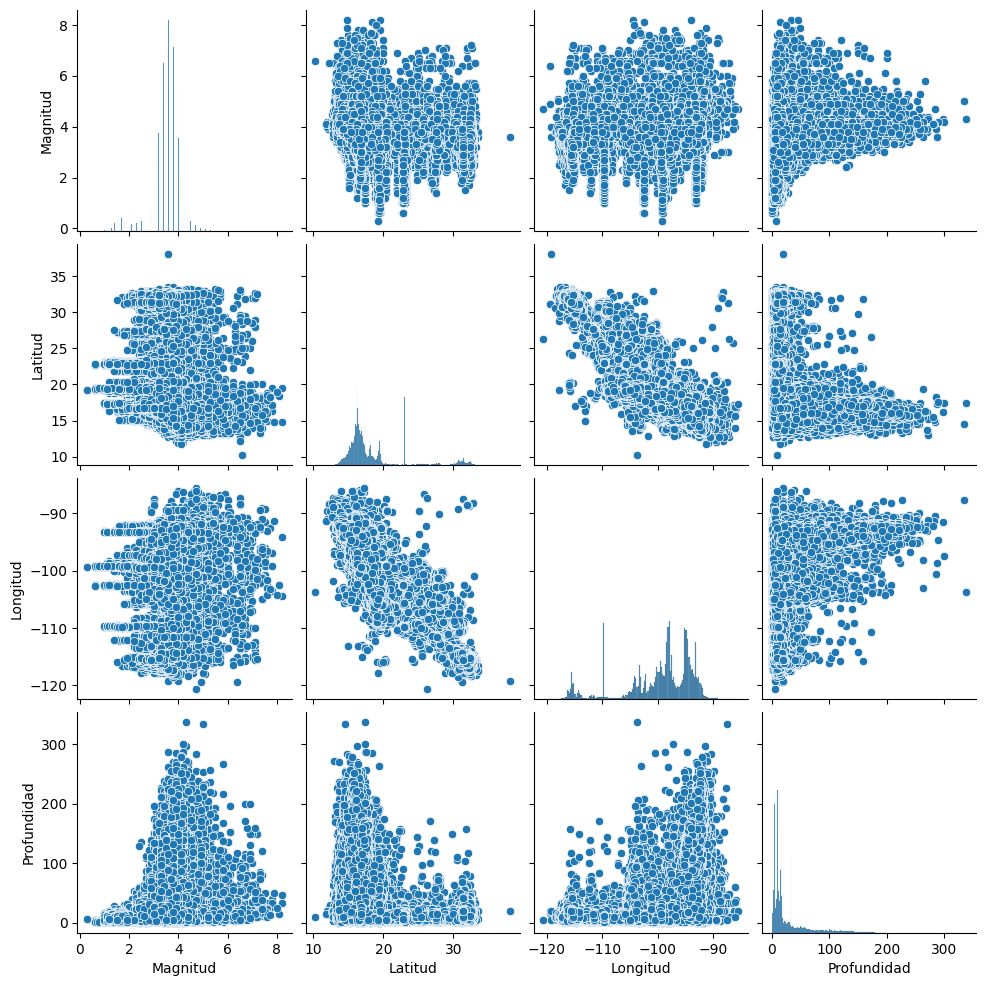

In [6]:
sns.pairplot(df_num)

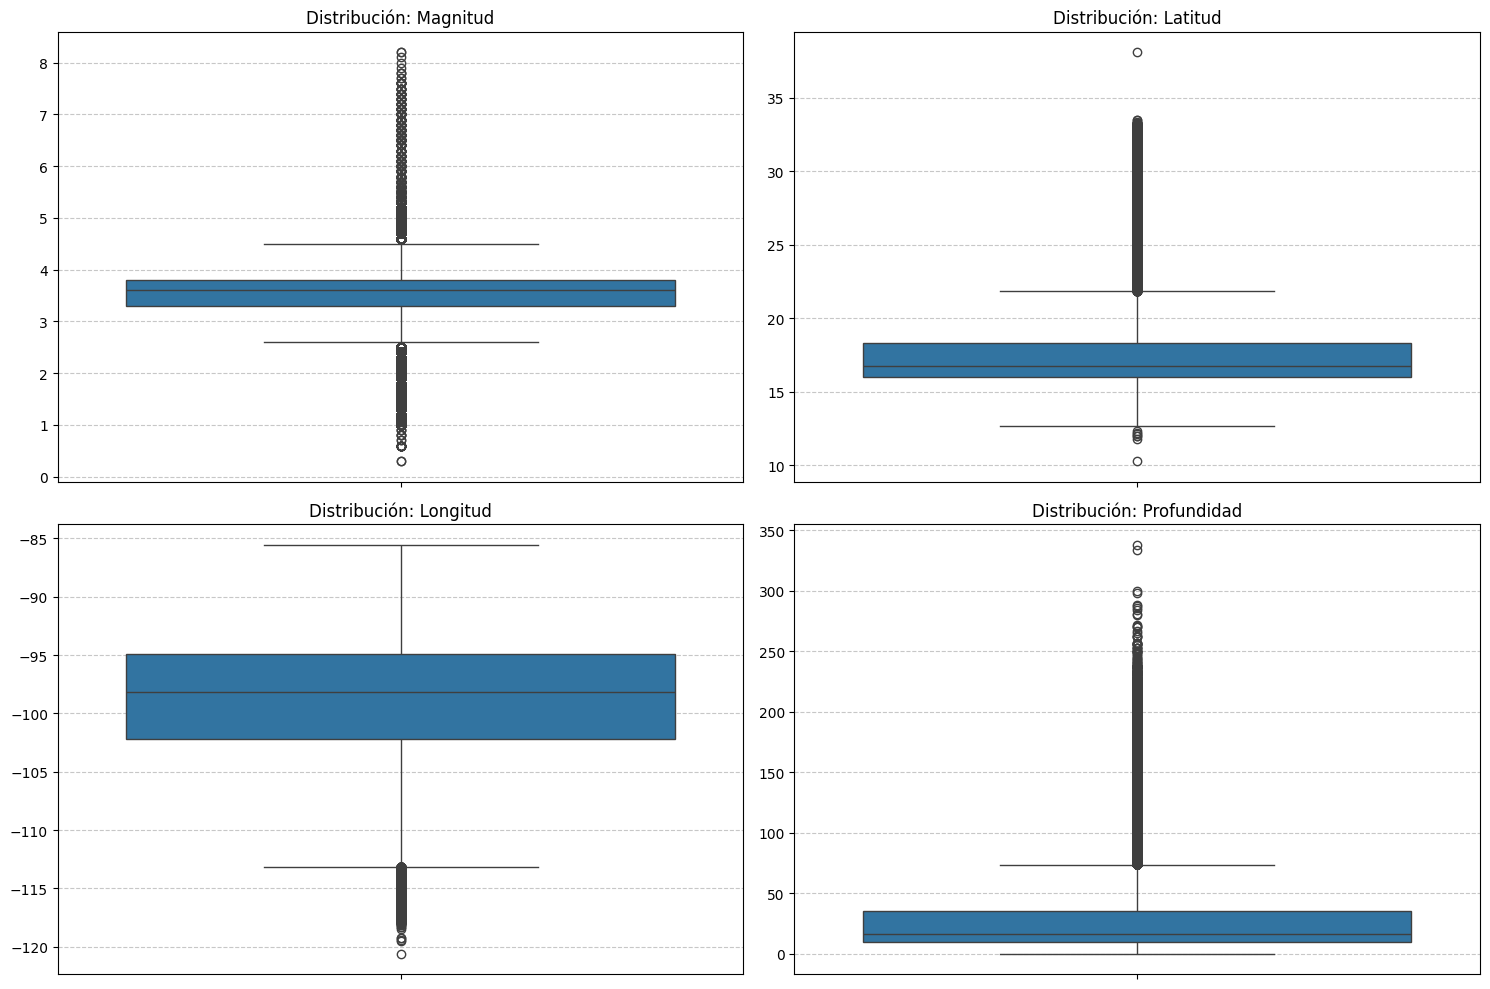

In [7]:
def graficar_outliers(df, columnas_por_fila=3):
    """Función que permite graficar Boxplots para todas las columnas de un dataset en una sola imagen"""
    columnas_numericas = df.select_dtypes(include=['number']).columns
    n_subs = len(columnas_numericas)
    n_filas = math.ceil(n_subs / columnas_por_fila) # Aseguramos que sea el número de columnas deseado
    
    fig, axes = plt.subplots(n_filas, columnas_por_fila, figsize=(15, n_filas * 5))
    axes = axes.flatten() # Para iterar en un solo ciclo

    for i, col in enumerate(columnas_numericas):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Distribución: {col}', fontsize=12)
        axes[i].set_ylabel('')
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off') # Para que no se muestren ejes vacíos sobrantes

    plt.tight_layout()
    plt.show()

graficar_outliers(df, 2)

En este caso, los valores fuera de los rangos esperados no son necesariamente *outliers*: Los sismos de magnitudes y lugares poco frecuentes podrían aportar bastante al análisis. Por ende, en el preprocesamiento, sólo se eliminarán los registros con magnitudes no convertibles a valores numéricos y aquellos cuyas coordenadas estén fuera del territorio mexicano.